In [22]:
import os
import json
import numpy as np

In [25]:
# TODO: make a class for each video?
def get_video_metadata(video_dir):
    gesture_dirs = [d for d in os.listdir(video_dir) if os.path.isdir(os.path.join(video_dir, d))]
    all_metadata = []
    for gesture_name in gesture_dirs:
        images_path = os.path.join(video_dir, gesture_name, "images")
        # Safely check if images_path contains any files
        if not os.path.exists(images_path): print(f"{images_path} does not exist"); continue
        image_dirs = [
            f
            for f in os.listdir(images_path)
        ]
        metadata_files = [os.path.join(images_path, d, "metadata.json") for d in image_dirs if (d.startswith(f"{gesture_name}") and os.path.exists(os.path.join(images_path, d, "metadata.json"))) ]

        # metadata_path = os.path.join(video_dir, gesture_name, "images/metadata.json")
        # print(f"Reading {metadata_path}")
        print(f"{gesture_name}: {len(image_dirs)} image files")
        print(metadata_files)
        all_metadata.extend(metadata_files)
    return all_metadata
    
def get_cropped_video_indices(video_metadata: dict):
    start, onset, end, n_frames = video_metadata["start_frame_idx"], video_metadata["action_frame_idx"], video_metadata["end_frame_idx"], video_metadata["total_frames"]
    return start, onset, end, n_frames

Check landmarks at cropeed video frames

In [ ]:
from scipy.spatial.distance import pdist

metadata_files = get_video_metadata("/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align")
LANDMARKS_DIR = "/Users/christina/code/RockPaperScissors/my_rps_dataset/features_coords"
durations = []
onsets = []
durations_per_class = {"rock": [], "paper": [], "scissors": []}

for meta_file in metadata_files:
    with open(meta_file, "r") as f:
        data = json.load(f)
    start, onset, end = get_cropped_video_indices(data)
    # print(f"Start: {start}, Onset: {onset}, End: {end}")
    vid_name = meta_file.split('/')[-2]
    landmarks_file = os.path.join(LANDMARKS_DIR, f"{vid_name}_landmarks.npz")
    landmarks_data = np.load(landmarks_file, allow_pickle=True)
    landmarks = landmarks_data["landmarks"][start:end+1]
    print(f"Number of NaNs in {landmarks_file}: {np.isnan(landmarks).sum()}")
    durations.append(end-start+1)
    onsets.append(onset-start+1)
    label = data.get("label")
    durations_per_class[label].append(end-start+1)


paper: 11 image files
['/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_49/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_38/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_36/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_31/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_37/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_45/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_20/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_35/metadata.json', '/Users/christina/code/RockPaperScissors/my_rps_dataset/data/align/paper/images/paper_50/metadata.json', '/Users/christina/code/RockPaper

Check cropped video duration and alignment

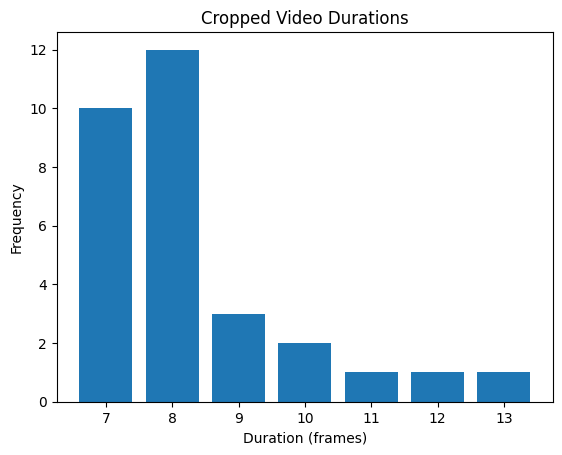

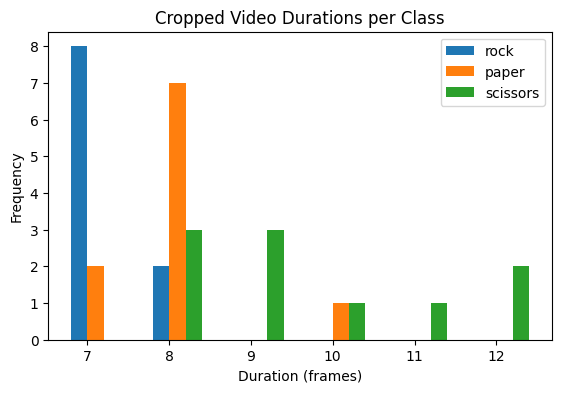

In [66]:
# Visualize duration and onset distributions
import matplotlib.pyplot as plt 

dur, count = np.unique(durations, return_counts=True)
plt.bar(dur, count, width=0.8, align='center')
plt.title("Cropped Video Durations")
plt.xlabel("Duration (frames)")
plt.ylabel("Frequency")
plt.show()

# Duration per class with grouped bars (side-by-side)
classes = list(durations_per_class.keys())
bins = np.arange(all_durations.min(), all_durations.max() + 1)
width = 0.2

plt.figure(figsize=(6.5, 4))
for i, gesture in enumerate(classes):
    counts, _ = np.histogram(durations_per_class[gesture], bins=bins)
    plt.bar(bins[:-1] + i * width, counts, width=width, align='edge', label=gesture)
plt.xticks(bins[:-1] + width, bins[:-1])
plt.title("Cropped Video Durations per Class")
plt.xlabel("Duration (frames)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

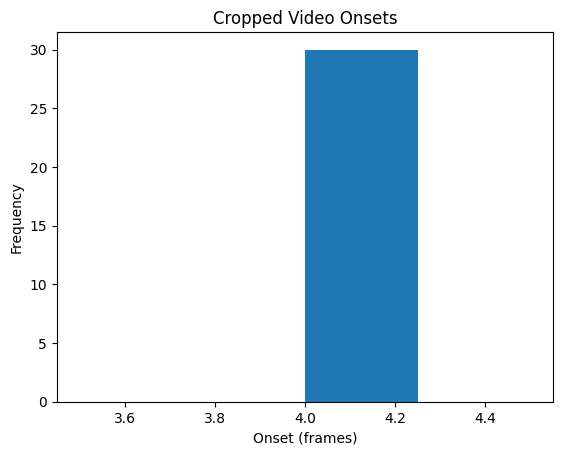

In [54]:
plt.hist(onsets, bins=4)
plt.title("Cropped Video Onsets")
plt.xlabel("Onset (frames)")
plt.ylabel("Frequency")
plt.show()

DTW